In [1]:
import os
os.chdir("/Users/hariniramanan/Desktop/Summer Work/pan")
os.getcwd()
os.listdir()


['labels.csv', 'data.csv']

In [2]:
import pandas as pd

X = pd.read_csv("data.csv")
y = pd.read_csv("labels.csv")

print(X.shape)
print(y.shape)

(801, 20532)
(801, 2)


In [3]:
X.head

<bound method NDFrame.head of      Unnamed: 0  gene_0    gene_1    gene_2    gene_3     gene_4  gene_5  \
0      sample_0     0.0  2.017209  3.265527  5.478487  10.431999     0.0   
1      sample_1     0.0  0.592732  1.588421  7.586157   9.623011     0.0   
2      sample_2     0.0  3.511759  4.327199  6.881787   9.870730     0.0   
3      sample_3     0.0  3.663618  4.507649  6.659068  10.196184     0.0   
4      sample_4     0.0  2.655741  2.821547  6.539454   9.738265     0.0   
..          ...     ...       ...       ...       ...        ...     ...   
796  sample_796     0.0  1.865642  2.718197  7.350099  10.006003     0.0   
797  sample_797     0.0  3.942955  4.453807  6.346597  10.056868     0.0   
798  sample_798     0.0  3.249582  3.707492  8.185901   9.504082     0.0   
799  sample_799     0.0  2.590339  2.787976  7.318624   9.987136     0.0   
800  sample_800     0.0  2.325242  3.805932  6.530246   9.560367     0.0   

       gene_6    gene_7  gene_8  ...  gene_20521  gene_20

In [4]:
y.head

<bound method NDFrame.head of      Unnamed: 0 Class
0      sample_0  PRAD
1      sample_1  LUAD
2      sample_2  PRAD
3      sample_3  PRAD
4      sample_4  BRCA
..          ...   ...
796  sample_796  BRCA
797  sample_797  LUAD
798  sample_798  COAD
799  sample_799  PRAD
800  sample_800  PRAD

[801 rows x 2 columns]>

In [5]:
X.info

<bound method DataFrame.info of      Unnamed: 0  gene_0    gene_1    gene_2    gene_3     gene_4  gene_5  \
0      sample_0     0.0  2.017209  3.265527  5.478487  10.431999     0.0   
1      sample_1     0.0  0.592732  1.588421  7.586157   9.623011     0.0   
2      sample_2     0.0  3.511759  4.327199  6.881787   9.870730     0.0   
3      sample_3     0.0  3.663618  4.507649  6.659068  10.196184     0.0   
4      sample_4     0.0  2.655741  2.821547  6.539454   9.738265     0.0   
..          ...     ...       ...       ...       ...        ...     ...   
796  sample_796     0.0  1.865642  2.718197  7.350099  10.006003     0.0   
797  sample_797     0.0  3.942955  4.453807  6.346597  10.056868     0.0   
798  sample_798     0.0  3.249582  3.707492  8.185901   9.504082     0.0   
799  sample_799     0.0  2.590339  2.787976  7.318624   9.987136     0.0   
800  sample_800     0.0  2.325242  3.805932  6.530246   9.560367     0.0   

       gene_6    gene_7  gene_8  ...  gene_20521  gene_

In [6]:
y.info

<bound method DataFrame.info of      Unnamed: 0 Class
0      sample_0  PRAD
1      sample_1  LUAD
2      sample_2  PRAD
3      sample_3  PRAD
4      sample_4  BRCA
..          ...   ...
796  sample_796  BRCA
797  sample_797  LUAD
798  sample_798  COAD
799  sample_799  PRAD
800  sample_800  PRAD

[801 rows x 2 columns]>

In [7]:
sample_ids_X = X["Unnamed: 0"]
sample_ids_y=y["Unnamed: 0"]
print((sample_ids_X == sample_ids_y).all())

True


In [8]:
X_features = X.drop(columns=["Unnamed: 0"])
y_labels = y["Class"]

print(X_features.shape)
print(y_labels.shape)
print(y_labels.value_counts())

(801, 20531)
(801,)
Class
BRCA    300
KIRC    146
LUAD    141
PRAD    136
COAD     78
Name: count, dtype: int64


In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_encoded = le.fit_transform(y_labels)

print(le.classes_)

['BRCA' 'COAD' 'KIRC' 'LUAD' 'PRAD']


In [11]:
for cls, num in zip(le.classes_, range(len(le.classes_))):
    print(f"{cls} = {num}")

BRCA = 0
COAD = 1
KIRC = 2
LUAD = 3
PRAD = 4


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_features,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(X_train.shape)
print(X_test.shape)

(640, 20531)
(161, 20531)


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=5000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [16]:
from sklearn.metrics import accuracy_score
y_pred = lr.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9813664596273292


In [17]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=le.classes_
    )
)

              precision    recall  f1-score   support

        BRCA       0.98      1.00      0.99        60
        COAD       0.94      0.94      0.94        16
        KIRC       1.00      1.00      1.00        30
        LUAD       0.96      0.93      0.95        28
        PRAD       1.00      1.00      1.00        27

    accuracy                           0.98       161
   macro avg       0.98      0.97      0.97       161
weighted avg       0.98      0.98      0.98       161



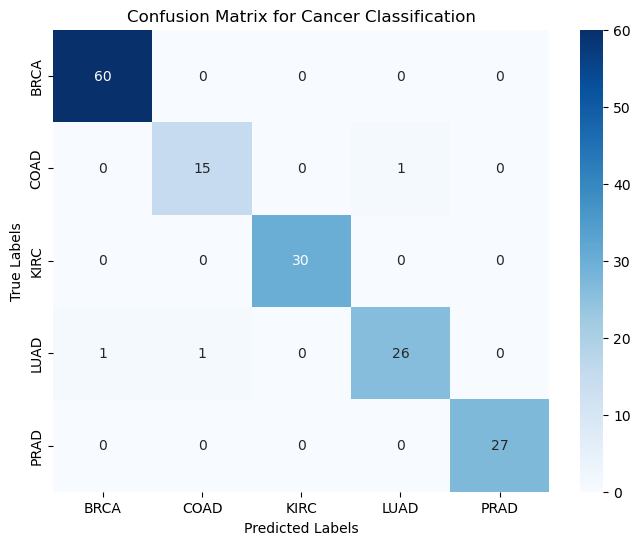

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate the matrix
cm = confusion_matrix(y_test, y_pred)
classes = ['BRCA', 'COAD', 'KIRC', 'LUAD', 'PRAD']

# Plotting
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix for Cancer Classification')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [19]:
import pandas as pd
import numpy as np

# Get the weights for all classes
coefficients = lr.coef_

# If your X_train was a pandas DataFrame, we can map weights back to gene names
# (Assuming your original features had gene names as columns)
gene_names = X_train.columns if hasattr(X_train, 'columns') else [f"Gene_{i}" for i in range(X_train.shape[1])]

# Create a dataframe for BRCA (class 0 in your alphabetized list)
brca_weights = pd.Series(coefficients[0], index=gene_names)
top_brca_genes = brca_weights.abs().sort_values(ascending=False).head(5)

print("Top 5 predictive genes for BRCA:")
print(top_brca_genes)

Top 5 predictive genes for BRCA:
gene_7964     0.015369
gene_17801    0.015168
gene_6876     0.014359
gene_6748     0.014268
gene_18746    0.014012
dtype: float64


In [20]:
train_accuracy = lr.score(X_train_scaled, y_train)
test_accuracy = lr.score(X_test_scaled, y_test)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")

Training Accuracy: 1.0000
Testing Accuracy: 0.9814


In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": lr,
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM (Linear)": SVC(kernel='linear', random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = {}
for name, model in models.items():
    # Fit the model
    model.fit(X_train_scaled, y_train)
    # Predict
    preds = model.predict(X_test_scaled)
    # Calculate accuracy
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")